<a href="https://colab.research.google.com/github/guslimaa777/45419370/blob/main/aula7_regressao_industrial_aluno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 7 — Algoritmos de regressão para previsão de variáveis industriais  
## Versão do aluno

**Objetivo da atividade**  
Construir e comparar modelos de regressão para prever a variável `vazao_real_l_min`, registrando as etapas do experimento e interpretando os resultados.

**Arquivo utilizado**  
`dados_aula7_regressao_industrial.csv`

## 1. Importação das bibliotecas

Preencha a célula abaixo com as bibliotecas necessárias para:
- manipulação dos dados;
- separação treino/validação;
- pré-processamento;
- criação dos modelos;
- cálculo das métricas.

In [2]:
# Escreva suas importações aqui

# Importe a biblioteca `pandas` utilizando o alias `pd` para manipulação de tabelas e datasets.
# Importe a biblioteca `numpy` utilizando o alias `np` para operações matemáticas e vetoriais.
# Importe a função `train_test_split` do módulo `sklearn.model_selection` para realizar a separação dos dados em treino e teste.
# Importe a classe `ColumnTransformer` do módulo `sklearn.compose` para aplicar diferentes transformações em grupos específicos de colunas.
# Importe a classe `Pipeline` do módulo `sklearn.pipeline` para organizar as etapas do pré-processamento e treinamento do modelo.
# Importe a classe `SimpleImputer` do módulo `sklearn.impute` para tratar valores ausentes no dataset.
# Importe:
# - `OneHotEncoder`
# - `StandardScaler`
# - `PolynomialFeatures`

# do módulo `sklearn.preprocessing` para:
# - codificação categórica
# - padronização de escalas
# - geração de atributos polinomiais

# Importe a classe `LinearRegression` do módulo `sklearn.linear_model` para construção do modelo de regressão linear.
# Importe:
# - `mean_absolute_error`
# - `mean_squared_error`
# - `r2_score`

# do módulo `sklearn.metrics` para avaliação do desempenho do modelo de regressão.
# Importe a biblioteca `matplotlib.pyplot` utilizando o alias `plt` para criação de gráficos e visualizações.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

## 2. Carregamento da base

Carregue o arquivo CSV e mostre:
- dimensão da base;
- cinco primeiras linhas;
- nomes das colunas.

In [4]:
# Carregue a base de dados nesta célula

# Utilize a função `pd.read_csv()` para carregar o arquivo:
# `"dados_aula7_regressao_industrial.csv"`

# Armazene o dataset em uma variável chamada `df`.
# Utilize `df.shape` para visualizar a dimensão da base de dados.

# Utilize `print()` para exibir a mensagem:
# `"Dimensão da base:"`
# Utilize `display(df.head())` para visualizar os primeiros registros da tabela.
# Utilize `df.columns.tolist()` para listar os nomes das colunas do dataset.

# Utilize `print()` para exibir a mensagem:
# `"Colunas:"`
# Exiba a lista de colunas presentes na base de dados.


In [3]:
df = pd.read_csv("dados_aula7_regressao_industrial.csv")

print("Dimensão da base:", df.shape)
display(df.head())
print("\nColunas:")
print(df.columns.tolist())

Dimensão da base: (266, 15)


,linha_producao,turno,produto_quimico,tipo_valvula,pressao_linha_bar,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,horas_operacao_bomba,particulas_ppm,viscosidade_cP,falha_operacional,vazao_real_l_min
0,Linha_B,Noite,Reagente_Y,Borboleta,7.20,29.54,41.56,3.90,6.71,122.07,1561,21.36,55.49,0,27.52
1,Linha_C,Tarde,Solvente_X,Borboleta,5.30,50.43,52.92,2.21,5.82,128.13,1501,19.75,48.70,0,36.80
2,Linha_B,Noite,Solvente_X,Globo,3.95,55.37,73.58,1.94,6.03,134.24,1188,21.45,15.00,0,45.95
3,Linha_B,Tarde,Aditivo_Z,Esfera,4.81,40.37,71.75,3.38,6.71,120.44,2095,13.30,48.18,0,49.50
4,Linha_A,Noite,Solvente_X,Borboleta,5.95,40.51,NaN,NaN,6.59,128.15,2003,11.58,55.20,0,46.66



Colunas:
['linha_producao', 'turno', 'produto_quimico', 'tipo_valvula', 'pressao_linha_bar', 'temperatura_produto_c', 'abertura_valvula_pct', 'vibracao_bomba_mm_s', 'ph_produto', 'consumo_energia_kwh', 'horas_operacao_bomba', 'particulas_ppm', 'viscosidade_cP', 'falha_operacional', 'vazao_real_l_min']


## 3. Inspeção inicial da base

Verifique:
- valores faltantes por coluna;
- tipos de dados;
- qual coluna será usada como variável-alvo.

**Pergunta para registro:**  
Por que este problema é classificado como regressão?

In [6]:
# Analise valores faltantes e tipos de dados

# Exiba uma mensagem utilizando `print()` para informar que será apresentada a quantidade de valores faltantes por coluna.
# Utilize:
# - `df.isna()`
# - `.sum()`

# para calcular a quantidade de valores ausentes em cada coluna do DataFrame.
# Utilize:
# - `.sort_values(ascending=False)`

# para ordenar os resultados do maior para o menor número de valores faltantes.
# Utilize a função `display()` para exibir o resultado formatado.
# Exiba uma nova mensagem utilizando `print()` para informar que serão apresentados os tipos de dados das colunas.
# Utilize:
# - `df.dtypes`

# para identificar os tipos de dados de cada coluna do DataFrame.
# Utilize novamente a função `display()` para exibir os tipos de dados formatados.


In [5]:
print("Valores faltantes por coluna:")
display(df.isna().sum().sort_values(ascending=False))

print("\nTipos de dados:")
display(df.dtypes)

Valores faltantes por coluna:


,0
abertura_valvula_pct,7
vibracao_bomba_mm_s,7
pressao_linha_bar,6
temperatura_produto_c,6
produto_quimico,5
turno,0
linha_producao,0
tipo_valvula,0
ph_produto,0
consumo_energia_kwh,0



Tipos de dados:


,0
linha_producao,object
turno,object
produto_quimico,object
tipo_valvula,object
pressao_linha_bar,float64
temperatura_produto_c,float64
abertura_valvula_pct,float64
vibracao_bomba_mm_s,float64
ph_produto,float64
consumo_energia_kwh,float64


## 4. Definição de X e y

Separe:
- `X`: variáveis preditoras;
- `y`: variável-alvo `vazao_real_l_min`.

Depois, mostre a dimensão de cada um.

In [7]:
# Separe X e y

# Crie uma variável chamada `X` para armazenar as variáveis de entrada do modelo.
# Utilize:
# `df.drop(columns=[ ])`
# Remova a coluna:
# `"vazao_real_l_min"`

# Crie uma variável chamada `y` para armazenar a variável alvo do modelo.
# Utilize:
# `df["vazao_real_l_min"]`

# Utilize:
# `X.shape`
# para visualizar a dimensão das variáveis de entrada.
# Utilize:
# `y.shape`

# para visualizar a dimensão da variável alvo.
# Utilize:
# `print()`

# para exibir:
# - dimensão de `X`
# - dimensão de `y`

# Utilize:
# `display(X.head())`

# para visualizar os primeiros registros de `X`.
# Utilize:
# `display(y.head())`
# para visualizar os primeiros registros de `y`.


In [8]:
X = df.drop(columns=["vazao_real_l_min"])
y = df["vazao_real_l_min"]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)
display(X.head())
display(y.head())

Dimensão de X: (266, 14)
Dimensão de y: (266,)


,linha_producao,turno,produto_quimico,tipo_valvula,pressao_linha_bar,temperatura_produto_c,abertura_valvula_pct,vibracao_bomba_mm_s,ph_produto,consumo_energia_kwh,horas_operacao_bomba,particulas_ppm,viscosidade_cP,falha_operacional
0,Linha_B,Noite,Reagente_Y,Borboleta,7.20,29.54,41.56,3.90,6.71,122.07,1561,21.36,55.49,0
1,Linha_C,Tarde,Solvente_X,Borboleta,5.30,50.43,52.92,2.21,5.82,128.13,1501,19.75,48.70,0
2,Linha_B,Noite,Solvente_X,Globo,3.95,55.37,73.58,1.94,6.03,134.24,1188,21.45,15.00,0
3,Linha_B,Tarde,Aditivo_Z,Esfera,4.81,40.37,71.75,3.38,6.71,120.44,2095,13.30,48.18,0
4,Linha_A,Noite,Solvente_X,Borboleta,5.95,40.51,NaN,NaN,6.59,128.15,2003,11.58,55.20,0


,vazao_real_l_min
0,27.52
1,36.80
2,45.95
3,49.50
4,46.66


## 5. Identificação das colunas numéricas e categóricas

Liste:
- colunas numéricas;
- colunas categóricas.

In [9]:
# Identifique as colunas numéricas e categóricas

# Utilize o método `select_dtypes()` para identificar automaticamente as colunas numéricas do DataFrame `X`.
# Configure o parâmetro `include` com:
# - `"int64"`
# - `"float64"`

# Utilize `.columns.tolist()` para converter os nomes das colunas em uma lista.
# Armazene o resultado em uma variável chamada `colunas_numericas`.

# Utilize novamente o método `select_dtypes()` para identificar as colunas categóricas.
# Configure o parâmetro `include` com:
# - `"object"`

# Utilize `.columns.tolist()` para transformar os nomes das colunas em lista.
# Armazene o resultado em uma variável chamada `colunas_categoricas`.

# Utilize `print()` para exibir o texto:
# - `"Colunas numéricas:"`

# Exiba o conteúdo da variável `colunas_numericas`.
# Utilize `print()` para exibir o texto:
# - `"Colunas categóricas:"`

# Exiba o conteúdo da variável `colunas_categoricas`.


In [23]:
colunas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
colunas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:")
print(colunas_numericas)

print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas numéricas:
['pressao_linha_bar', 'temperatura_produto_c', 'abertura_valvula_pct', 'vibracao_bomba_mm_s', 'ph_produto', 'consumo_energia_kwh', 'horas_operacao_bomba', 'particulas_ppm', 'viscosidade_cP', 'falha_operacional']

Colunas categóricas:
['linha_producao', 'turno', 'produto_quimico', 'tipo_valvula']


## 6. Construção do pré-processamento

Monte um pipeline com:

### Para colunas numéricas
- preenchimento de faltantes com mediana;
- padronização.

### Para colunas categóricas
- preenchimento com valor mais frequente;
- codificação com `OneHotEncoder`.

Depois, una tudo em um `ColumnTransformer`.

In [24]:
# Monte o preprocessador aqui

# Crie um Pipeline utilizando a função `Pipeline()` para realizar o tratamento das colunas numéricas.
# Armazene o Pipeline em uma variável chamada `transformador_numerico`.
# Adicione uma etapa chamada `"imputer"` utilizando `SimpleImputer()`.
# Configure o parâmetro:
# - `strategy="median"`

# Adicione uma etapa chamada `"scaler"` utilizando `StandardScaler()`.
# Crie um segundo Pipeline para tratamento das colunas categóricas.
# Armazene esse Pipeline em uma variável chamada `transformador_categorico`.
# Adicione uma etapa chamada `"imputer"` utilizando `SimpleImputer()`.
# Configure o parâmetro:
# - `strategy="most_frequent"`

# Adicione uma etapa chamada `"onehot"` utilizando `OneHotEncoder()`.
# Configure o parâmetro:
# - `handle_unknown="ignore"`

# Crie um `ColumnTransformer()` para unificar os pré-processamentos.
# Armazene o transformador em uma variável chamada `preprocessador`.
# Adicione um transformador chamado `"num"` utilizando:
# - `transformador_numerico`
# - `colunas_numericas`

# Adicione um transformador chamado `"cat"` utilizando:
# - `transformador_categorico`
# - `colunas_categoricas`

# Finalize exibindo a variável:
# - `preprocessador`


In [27]:
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessador = ColumnTransformer(transformers=[
    ("num", transformador_numerico, colunas_numericas),
    ("cat", transformador_categorico, colunas_categoricas)
])

preprocessador

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['pressao_linha_bar', 'temperatura_produto_c',
                                  'abertura_valvula_pct', 'vibracao_bomba_mm_s',
                                  'ph_produto', 'consumo_energia_kwh',
                                  'horas_operacao_bomba', 'particulas_ppm',
                                  'viscosidade_cP', 'falha_operacional']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['linha_producao', 'turno', 'produto_quimico',
                                  'tipo_valvula'])])

## 7. Separação dos dados em treino e validação

Realize a separação dos dados usando:
- `test_size=0.2`
- `random_state=42`

Mostre as dimensões de:
- `X_treino`
- `X_validacao`
- `y_treino`
- `y_validacao`

**Registro técnico:**  
Explique, com suas palavras, por que não devemos treinar e avaliar no mesmo conjunto de dados.

In [ ]:
# Faça a separação treino/validação

# Utilize a função `train_test_split()` para separar os dados em treino e validação.
# Crie as variáveis:
# - `X_treino`
# - `X_validacao`
# - `y_treino`
# - `y_validacao`
# Utilize:
# - `X`
# - `y`
# Configure o parâmetro:
# - `test_size=0.2`
# Configure o parâmetro:
# - `random_state=42`

# Utilize o método `.shape` para verificar o tamanho das bases geradas.

# Utilize `print()` para exibir:
# - `X_treino`
# - `X_validacao`
# - `y_treino`
# - `y_validacao`

# Exiba as dimensões das bases de treino e validação após a separação dos dados.

In [28]:
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dimensão X_treino:", X_treino.shape)
print("Dimensão X_validacao:", X_validacao.shape)
print("Dimensão y_treino:", y_treino.shape)
print("Dimensão y_validacao:", y_validacao.shape)

Dimensão X_treino: (212, 14)
Dimensão X_validacao: (54, 14)
Dimensão y_treino: (212,)
Dimensão y_validacao: (54,)


## 8. Criação do modelo de regressão linear

Monte um pipeline contendo:
- pré-processamento;
- `LinearRegression`.

###***Pergunta de Negocio***

"Podemos estimar a vazão real de uma máquina a partir das condições operacionais?"

In [29]:
# Crie o modelo linear

# Crie um Pipeline utilizando a função `Pipeline()` para organizar as etapas do modelo.
# Armazene o Pipeline em uma variável chamada `modelo_linear`.
# Utilize o parâmetro `steps=[]` para definir as etapas do Pipeline.
# Adicione uma etapa chamada `"preprocessamento"` utilizando a variável `preprocessador`.
# Adicione uma etapa chamada `"modelo"` utilizando o algoritmo `LinearRegression()`.
# Finalize exibindo a variável `modelo_linear` para visualizar a estrutura do Pipeline.


In [30]:
modelo_linear = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", LinearRegression())
])

modelo_linear

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pressao_linha_bar',
                                                   'temperatura_produto_c',
                                                   'abertura_valvula_pct',
                                                   'vibracao_bomba_mm_s',
                                                   'ph_produto',
                                                   'consumo_energia_kwh',
                                                   'horas_operacao_bomba',
                                                   'particulas_ppm',
                                                   'viscosidade_cP',
                                                   'falha_operacional']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['linha_producao', 'turno',
                                                   'produto_quimico',
                                                   'tipo_valvula'])])),
                ('modelo', LinearRegression())])

## 9. Treinamento do modelo linear

Treine o modelo usando os dados de treino.

In [ ]:
# Treine o modelo linear

# Utilize o método `.fit()` para treinar o modelo de regressão linear.
# Utilize:
# - `X_treino`
# - `y_treino`

# como dados de treinamento do modelo.
# Execute o treinamento utilizando a variável `modelo_linear`.
# Após o treinamento, utilize a função `print()` para exibir uma mensagem de confirmação.
# Exiba a mensagem:

# `"Modelo linear treinado com sucesso."`


In [31]:
modelo_linear.fit(X_treino, y_treino)
print("Modelo linear treinado com sucesso.")

Modelo linear treinado com sucesso.


## 10. Predição com o modelo linear

Use os dados de validação para gerar previsões e mostre as primeiras comparações entre:
- valor real;
- valor previsto.

In [32]:
# Gere predições com o modelo linear

# Gere previsões utilizando o método `.predict()` aplicado sobre `X_validacao`.

# Armazene as previsões em uma variável chamada `pred_linear`.

# Crie um `DataFrame` utilizando `pd.DataFrame()` para organizar:
# - os valores reais
# - os valores previstos
# Adicione uma coluna chamada `"valor_real"` utilizando:
# - `y_validacao.values`
# Adicione uma coluna chamada `"predicao_linear"` utilizando:
# - `pred_linear`

# Armazene o DataFrame em uma variável chamada `resultado_linear`.
# Utilize:
# - `display()`
# - `.head(10)`

# para exibir os 10 primeiros resultados da comparação entre:
# - valor real
# - previsão do modelo linear.


In [33]:
pred_linear = modelo_linear.predict(X_validacao)

resultado_linear = pd.DataFrame({
    "valor_real": y_validacao.values,
    "predicao_linear": pred_linear
})

display(resultado_linear.head(10))

,valor_real,predicao_linear
0,34.19,31.613671
1,34.49,34.909643
2,25.94,17.411885
3,47.04,43.961261
4,38.92,41.792494
5,36.41,39.429888
6,36.49,40.983627
7,38.42,42.165993
8,40.51,44.683560
9,24.74,22.284348


## 11. Métricas do modelo linear

Calcule:
- MAE
- RMSE
- R²

Depois, registre uma interpretação breve:
- o erro ficou alto ou baixo?
- o R² indica bom ajuste?

In [35]:
# Calcule as métricas do modelo linear

# Armazene o resultado em uma variável chamada `mae_linear`.
# Calcule o erro absoluto médio utilizando a função `mean_absolute_error()` comparando:
# - `y_validacao`
# - `pred_linear`

# Armazene o resultado em uma variável chamada `rmse_linear`.
# Calcule o erro quadrático médio utilizando a função `mean_squared_error()`.
# Utilize:
# - `y_validacao`
# - `pred_linear`

# Armazene o resultado em uma variável chamada `r2_linear`.
# Calcule o coeficiente de determinação utilizando a função `r2_score()`.
# Utilize:
# - `y_validacao`
# - `pred_linear`

# Utilize o método `print()` para exibir o título:
# `"Métricas - Regressão Linear"`

# Utilize `print()` com `f-string` para exibir:
# - MAE
# - RMSE
# - R²

# Utilize a formatação:
# `.4f`

# para exibir os valores com quatro casas decimais.


In [61]:
mae_linear = mean_absolute_error(y_validacao, pred_linear)
rmse_linear = mean_squared_error(y_validacao, pred_linear)
r2_linear = r2_score(y_validacao, pred_linear)

print("Métricas - Regressão Linear")
print(f"MAE : {mae_linear:.4f}")
print(f"RMSE: {rmse_linear:.4f}")
print(f"R²  : {r2_linear:.4f}")

Métricas - Regressão Linear
MAE : 2.9592
RMSE: 14.5833
R²  : 0.7368


# Explicação:

# **Regressão Linear**

Foram calculadas três métricas principais:

---

# **MAE (Erro Médio Absoluto)**

```txt id="e3t9mx"
MAE: 2.9592
```

Mostra o erro médio das previsões.

Isso significa que:

* o modelo erra aproximadamente `2.95` unidades em média, as previsões do modelo ficaram aproximadamente 2,96 L/min distantes dos valores reais.

Quanto menor:

* melhor.

---

# **RMSE**

```txt id="hgm9qu"
RMSE: 14.5833
```

Mede o tamanho dos erros dando mais peso para erros grandes.

> o RMSE fica na mesma unidade da variável-alvo, portanto: <br/>
> Se a vazão real for: <br/>
> 50 L/min </br>
> O modelo pode produzir previsões como: <br/>
> * 36 L/min
> * 64 L/min
> * 47 L/min

Quanto menor:

* melhor o ajuste do modelo.

---

# **R² (Coeficiente de Determinação)**

```txt id="30a1j4"
R²: 0.7368
```

Mostra quanto o modelo conseguiu explicar os dados.

Nesse caso:

* o modelo explica aproximadamente `73%` do comportamento dos dados.

Quanto mais próximo de:

1

melhor.

---
> o modelo de regressão linear conseguiu gerar previsões razoavelmente próximas dos valores reais, apresentando desempenho moderadamente bom.


## 12. Criação do modelo polinomial

Monte um segundo pipeline com:
- imputação;
- padronização;
- `PolynomialFeatures(degree=2)`;
- `LinearRegression`.

Use codificação categórica para as colunas de texto.

# ***Pergunta de negócio***

"É possível prever a vazão real de um processo industrial considerando relações não lineares entre as condições operacionais?"

In [37]:
# Crie o modelo polinomial

# Crie um Pipeline utilizando a função `Pipeline()` para organizar as etapas de transformação numérica polinomial.
# Armazene o Pipeline em uma variável chamada `transformador_numerico_polinomial`.

# Adicione uma etapa chamada `"imputer"` utilizando `SimpleImputer()`.
# Configure o parâmetro:
# - `strategy="median"`

# Adicione uma etapa chamada `"scaler"` utilizando `StandardScaler()`.
# Adicione uma etapa chamada `"poly"` utilizando `PolynomialFeatures()`.
# Configure os parâmetros:
# - `degree=2`

# Crie um `ColumnTransformer()` para combinar transformações numéricas e categóricas.
# Armazene o transformador em uma variável chamada `preprocessador_polinomial`.

# Adicione uma transformação chamada `"num"` utilizando:
# - `transformador_numerico_polinomial`
# - `colunas_numericas`

# Adicione uma transformação chamada `"cat"` utilizando:
# - `transformador_categorico`
# - `colunas_categoricas`

# Crie um novo Pipeline utilizando `Pipeline()` para montar o modelo de regressão polinomial.
# Armazene o Pipeline em uma variável chamada `modelo_polinomial`.

# Adicione uma etapa chamada `"preprocessamento"` utilizando:
# - `preprocessador_polinomial`

# Adicione uma etapa chamada `"modelo"` utilizando:
# - `LinearRegression()`

# Finalize exibindo a variável:
# - `modelo_polinomial`


In [42]:
transformador_numerico_polinomial = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2))
])

preprocessador_polinomial = ColumnTransformer(transformers=[
    ("num", transformador_numerico_polinomial, colunas_numericas),
    ("cat", transformador_categorico, colunas_categoricas)
])

modelo_polinomial = Pipeline(steps=[
    ("preprocessamento", preprocessador_polinomial),
    ("modelo", LinearRegression())
])

modelo_polinomial


Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures())]),
                                                  ['pressao_linha_bar',
                                                   'temperatura_produto_c',
                                                   'abertura_valvula_pct',
                                                   'vibracao_bomba_mm_s',
                                                   'ph_produto',
                                                   'consumo_energia_kwh',
                                                   'horas_operacao_bomba',
                                                   'particulas_ppm',
                                                   'viscosidade_cP',
                                                   'falha_operacional']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['linha_producao', 'turno',
                                                   'produto_quimico',
                                                   'tipo_valvula'])])),
                ('modelo', LinearRegression())])

## 13. Treinamento do modelo polinomial

Treine o segundo modelo com os dados de treino.

In [43]:
# Treine o modelo polinomial

# Utilize o método `.fit()` para treinar o modelo polinomial.
# Utilize:
# - `X_treino`
# - `y_treino`

# como dados de treinamento do modelo.
# Utilize o método `print()` para exibir uma mensagem de confirmação do treinamento.

# Exiba a mensagem:
# `"Modelo polinomial treinado com sucesso."`


In [44]:
modelo_polinomial.fit(X_treino, y_treino)
print("Modelo polinomial treinado com sucesso.")

Modelo polinomial treinado com sucesso.


## 14. Predição com o modelo polinomial

Gere as predições usando os dados de validação.

In [45]:
# Gere as predições do modelo polinomial

# Utilize o método `.predict()` para gerar previsões utilizando o modelo `modelo_polinomial`.
# Utilize `X_validacao` como entrada para a previsão do modelo.
# Armazene o resultado das previsões em uma variável chamada `pred_polinomial`.

# Crie um `DataFrame` utilizando `pd.DataFrame()` para organizar os resultados da validação.
# Adicione uma coluna chamada `"valor_real"` utilizando:
# - `y_validacao.values`

# Adicione uma coluna chamada `"predicao_polinomial"` utilizando:
# - `pred_polinomial`

# Armazene o DataFrame em uma variável chamada `resultado_polinomial`.
# Utilize:
# - `display()`
# - `.head(10)`

# para exibir os 10 primeiros resultados da comparação entre:
# - valores reais
# - previsões do modelo polinomial.


In [46]:
pred_polinomial = modelo_polinomial.predict(X_validacao)

resultado_polinomial = pd.DataFrame({
    "valor_real": y_validacao.values,
    "predicao_polinomial": pred_polinomial
})

display(resultado_polinomial.head(10))

,valor_real,predicao_polinomial
0,34.19,31.895331
1,34.49,33.277253
2,25.94,18.792153
3,47.04,42.105483
4,38.92,37.425947
5,36.41,39.812929
6,36.49,41.550155
7,38.42,39.473158
8,40.51,44.689113
9,24.74,19.616535


#Explicando ***PolynomialFeatures***

>PolynomialFeatures cria novas variáveis a partir das existentes, permitindo que o modelo identifique relações quadráticas e combinações entre as variáveis.

Ex:
Imagine que temos duas variáveis:

* temperatura
* pressao

Sem PolynomialFeatures, o modelo recebe apenas:
* temperatura
* pressao

Qaundo usamos
PolynomialFeatures(degree=2, include_bias=False)
ele cria:
* temperatura
* pressao
* temperatura²
* temperatura × pressao
* pressao²


O que significa degree=2?

Significa que queremos criar relações até o segundo grau.

Por exemplo:

$$ x $$

vira:

$$x,x2$$

E, quando temos duas variáveis:

$$ x,\ y $$

podemos ter:

$$x, y, x2, xy, y2$$


>Ele aumenta as informações disponíveis para o modelo, criando combinações e potências das variáveis numéricas.

#Explicação:

# **Regressão Polinomial**

---

# **O que aconteceu**

O modelo utilizou:

```python id="4by98m"
modelo_polinomial.predict(X_validacao)
```

para prever valores numéricos utilizando relações mais complexas entre as variáveis.

> "A Regressão Linear procura uma linha reta; a Regressão Polinomial permite que o modelo represente curvas e combinações entre variáveis."

---

# **Tabela apresentada**

A tabela compara:

* `valor_real`
* `predicao_polinomial`

---

# **Exemplo**

| Valor real | Predição |
| ---------- | -------- |
| 34.19      | 31.89    |

Isso significa que:

* o valor verdadeiro era `34.19`
* o modelo previu `31.89`

---

# **Diferença para regressão linear**

A regressão polinomial consegue aprender:

* curvas
* comportamentos não lineares
* relações matemáticas mais complexas

Isso pode melhorar as previsões em cenários industriais mais sofisticados.

---
> o modelo polinomial está realizando previsões numéricas utilizando relações matemáticas mais avançadas para tentar se aproximar melhor dos valores reais.


## 15. Métricas do modelo polinomial

Calcule:
- MAE
- RMSE
- R²

In [47]:
# Calcule as métricas do modelo polinomial

# Armazene o resultado em uma variável chamada `mae_polinomial`.
# Calcule o erro absoluto médio utilizando a função `mean_absolute_error()`.
# Utilize:
# - `y_validacao`
# - `pred_polinomial`

# Armazene o resultado em uma variável chamada `rmse_polinomial`.
# Calcule o erro quadrático médio utilizando a função `mean_squared_error()`.

# Utilize:
# - `y_validacao`
# - `pred_polinomial`

# Armazene o resultado em uma variável chamada `r2_polinomial`.
# Calcule o coeficiente de determinação utilizando a função `r2_score()`.
# Utilize:
# - `y_validacao`
# - `pred_polinomial`

# Utilize o método `print()` para exibir o título:
# `"Métricas - Regressão Polinomial"`

# Utilize:
# - `print()`
# - `f-string`

# para exibir:
# - MAE
# - RMSE
# - R²

# Formate os valores utilizando:
# `.4f`

# para exibir apenas 4 casas decimais.


In [64]:
mae_polinomial = mean_absolute_error(y_validacao, pred_polinomial)
rmse_polinomial =mean_squared_error(y_validacao, pred_polinomial)
r2_polinomial = r2_score(y_validacao, pred_polinomial)

print("Métricas - Regressão Polinomial")
print(f"MAE : {mae_polinomial:.4f}")
print(f"RMSE: {rmse_polinomial:.4f}")
print(f"R²  : {r2_polinomial:.4f}")

Métricas - Regressão Polinomial
MAE : 3.5661
RMSE: 17.5004
R²  : 0.6841


## 16. Comparação entre modelos

Monte uma tabela com as métricas dos dois modelos e responda:

1. Qual modelo teve menor erro?
2. Qual modelo apresentou melhor capacidade explicativa?
3. Qual modelo você recomendaria para este problema?

In [ ]:
# Monte a tabela comparativa

# Crie um DataFrame utilizando a função `pd.DataFrame()` para comparar os resultados dos modelos de regressão.
# Armazene o DataFrame em uma variável chamada `comparacao`.

# Crie uma coluna chamada `"Modelo"` contendo:
# - `"Regressão Linear"`
# - `"Regressão Polinomial"`

# Crie uma coluna chamada `"MAE"` utilizando:
# - `mae_linear`
# - `mae_polinomial`

# Crie uma coluna chamada `"RMSE"` utilizando:
# - `rmse_linear`
# - `rmse_polinomial`

# Crie uma coluna chamada `"R2"` utilizando:
# - `r2_linear`
# - `r2_polinomial`

# Utilize a função `display()` para exibir o DataFrame.
# Utilize o método `.sort_values()` para ordenar os resultados pela coluna `"RMSE"`.

# Informe o parâmetro:
# - `by="RMSE"`

# Exiba a comparação final dos modelos ordenada pelo menor erro RMSE.


In [58]:
comparacao = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Regressão Polinomial"],
    "MAE": [mae_linear, mae_polinomial],
    "RMSE": [rmse_linear, rmse_polinomial],
    "R2": [r2_linear, r2_polinomial]
})

display(comparacao.sort_values(by="RMSE"))

,Modelo,MAE,RMSE,R2
0,Regressão Linear,2.959205,3.818805,0.736763
1,Regressão Polinomial,3.566114,4.183350,0.684107


### Espaço do aluno

Comparação entre dois modelos de regressão?<br/>
R: A comparação mostra qual modelo se ajusta melhor aos dados observados.
<br/>
Quais modelos foram usados? <br/>
R: Regressão Linear e Regressão Polinomial.
<br/>
O que a tabela dec comparação mostra? </br>
R:Mostra os valores de desempenho dos dois modelos, permitindo comparar qual apresenta melhor ajuste aos dados.
<br/>
Resultado observado<br/>
Regressão Linear:<br/>
R: Apresentou um ajuste em forma de linha reta, adequado quando a relação entre as variáveis é aproximadamente linear.
<br/>
Regressão Polinomial:<br/>
R:Apresentou um ajuste curvo, capaz de representar relações mais complexas entre as variáveis.




## 17. Visualização dos resultados

Crie um gráfico comparando:
- valores reais;
- predição linear;
- predição polinomial.

In [60]:
# Crie um gráfico comparativo

# Crie uma figura utilizando o método `plt.figure()`.
# Configure a propriedade:
# - `figsize=(10,6)`

# Utilize o método `plt.plot()` para plotar os valores reais utilizando:
# - `y_validacao.values[:30]`
# Configure a propriedade:
# - `label="Valor real"`

# Utilize novamente o método `plt.plot()` para plotar as predições do modelo linear utilizando:
# - `pred_linear[:30]`

# Configure a propriedade:
# - `label="Predição linear"`

# Utilize novamente o método `plt.plot()` para plotar as predições do modelo polinomial utilizando:
# - `pred_polinomial[:30]`
# Configure a propriedade:
# - `label="Predição polinomial"`

# Adicione um título utilizando o método `plt.title()`.
# Defina o texto:
# - `"Comparação entre valores reais e predições"`

# Configure o eixo X utilizando `plt.xlabel()`.

# Defina o texto:
# - `"Amostras"`

# Configure o eixo Y utilizando `plt.ylabel()`.
# Defina o texto:
# - `"Vazão real (L/min)"`

# Utilize o método `plt.legend()` para exibir a legenda do gráfico.
# Finalize utilizando `plt.show()` para exibir o gráfico.


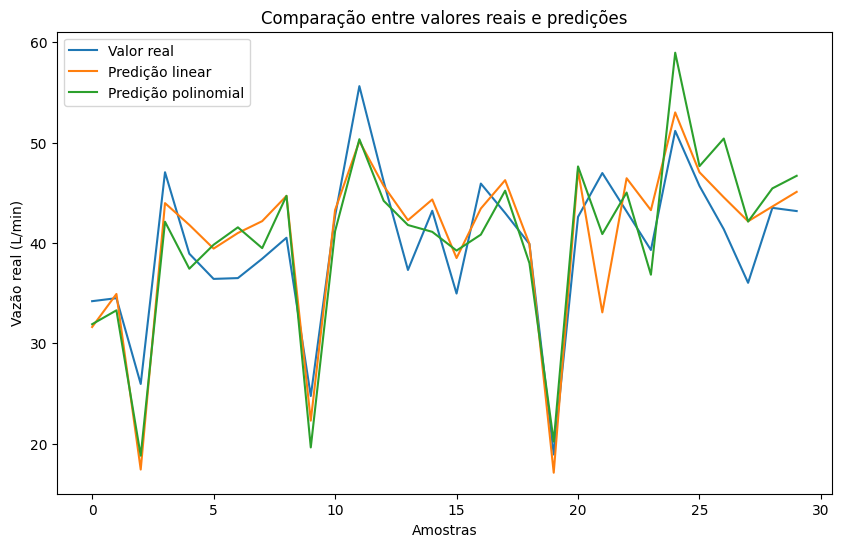

In [59]:
plt.figure(figsize=(10,6))
plt.plot(y_validacao.values[:30], label="Valor real")
plt.plot(pred_linear[:30], label="Predição linear")
plt.plot(pred_polinomial[:30], label="Predição polinomial")
plt.title("Comparação entre valores reais e predições")
plt.xlabel("Amostras")
plt.ylabel("Vazão real (L/min)")
plt.legend()
plt.show()

## 18. Reflexão final

Responda no notebook:

- Qual a função da etapa de treino?
Ensinar o modelo a identificar padrões nos dados e ajustar seus parâmetros para fazer previsões.
- Qual a função da etapa de validação?
 Avaliar o desempenho do modelo em dados que não foram usados diretamente no treinamento e ajudar a verificar se ele está generalizando bem.
- Por que as métricas são importantes?
Porque permitem medir o desempenho do modelo e comparar os resultados, identificando se as previsões estão adequadas.
- Em que situação a regressão logística seria mais apropriada do que a regressão linear?
Quando o objetivo é classificar os dados em categorias, especialmente quando o resultado é binário, como sim/não, aprovado/reprovado ou doente/saudável. A regressão linear é mais indicada para prever valores numéricos contínuos.